# Sentiment Analysis using Word Embeddings
### Register Number: 23BAI1589 (Yashvanth Karunakaran)

### AIM:
### Word-embedding-based sentiment classification system using the NLTK product_reviews_1 corpus.

### Downloading the Dataset

In [1]:
import nltk
nltk.download('product_reviews_1')
corpus=nltk.corpus.product_reviews_1

[nltk_data] Downloading package product_reviews_1 to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package product_reviews_1 is already up-to-date!


### Preparation of Dataset

Creating a reviews dataframe from NLTK product review corpus, each review has a title, review text and sentiment polarity. just iterating through all review in the corpus, extracting the title then combining all sentences from review lines into a single review text. calculating overall sentiment score by adding all the reviews sentiment and then assigned the sentiment score. then creating pandas dataframe

In [2]:
import pandas as pd
import numpy as np

review_titles=[]
review_texts=[]
review_sentiments=[]

for review in corpus.reviews():
    title=review.title
    full_review_text=' '.join([' '.join(line.sent) for line in review.review_lines])
    total_sentiment_score=0
    for line in review.review_lines:
        for feature, sentiment_str in line.features:
            score=int(sentiment_str)
            total_sentiment_score+=score

    if total_sentiment_score>0:
        sentiment_label='positive'
    elif total_sentiment_score<0:
        sentiment_label='negative'
    else:
        sentiment_label='neutral'

    review_titles.append(title)
    review_texts.append(full_review_text)
    review_sentiments.append(sentiment_label)


df_reviews = pd.DataFrame({'title': review_titles,'review_text':review_texts,'sentiment':review_sentiments})

df_reviews.head()

,title,review_text,sentiment
0,troubleshooting ad-2500 and ad-2600 no picture...,"repost from january 13 , 2004 with a better fi...",positive
1,incredibe price / performance .,i ' ve owned 6 or 7 dvd players since 1998 . t...,positive
2,doesnt play new disney movies .,many of our disney movies do n ' t play on thi...,negative
3,poor quality - problem with dual-layer dvd 's .,player has a problem with dual - layer dvd ' s...,negative
4,has destroyed several of my dvds and cds .,"for the first few weeks , this player was ever...",negative


#### Checking the sentiment distribution

In [3]:
df_reviews['sentiment'].value_counts()

,count
sentiment,
positive,188
negative,109
neutral,16


### Text Preprocessing
#### Keeping vocabulary size as 10000
#### padding length as 100
#### enabling OOV token

Combining review title and text for sentiment analysis to achieve better result. padding inorder to make all sentences of equal length

In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer=Tokenizer(num_words=10000,oov_token='<OOV>')
tokenizer.fit_on_texts(df_reviews['title']+df_reviews['review_text'])

sequences=tokenizer.texts_to_sequences(df_reviews['title']+df_reviews['review_text'])
padded_sequences=pad_sequences(sequences,maxlen=100,padding='post',truncating='post')

#### Checking tokenizing and padding result

In [5]:
(df_reviews['title']+df_reviews['review_text'])[0]

"troubleshooting ad-2500 and ad-2600 no picture scrolling b/w .repost from january 13 , 2004 with a better fit title . does your apex dvd player only play dvd audio without video ? or does it play audio and video but scrolling in black and white ? before you try to return the player or waste hours calling apex tech support , or run the player over with your car , try these simple troubleshooting ideas first . no picture : hopefully you still have the remote control . if you tossed it out the window , you need to fetch it . using the remote control , press the i / p button located on the bottom right corner of the remote . the i / p button switches the tv display between interlace and progressive . if this doesnt bring back the picture , try pressing this button without playing a dvd . if you dont get video back , now you can run the player over with your car ! picture scrolling in b / w : you need the remote control for this so you better get it from your dog before he burries it in th

#### Corpus words of 10000 vocabulary tokenized with index

In [6]:
tokenizer.word_index.items()

dict_items([('<OOV>', 1), ('the', 2), ('i', 3), ('to', 4), ('and', 5), ('a', 6), ('it', 7), ('is', 8), ("'", 9), ('of', 10), ('you', 11), ('this', 12), ('for', 13), ('that', 14), ('with', 15), ('in', 16), ('have', 17), ('my', 18), ('on', 19), ('not', 20), ('t', 21), ('but', 22), ('player', 23), ('s', 24), ('are', 25), ('as', 26), ('can', 27), ('n', 28), ('camera', 29), ('was', 30), ('be', 31), ('if', 32), ('so', 33), ('one', 34), ('all', 35), ('phone', 36), ('very', 37), ('great', 38), ('do', 39), ('an', 40), ('has', 41), ('at', 42), ('use', 43), ('about', 44), ('had', 45), ('good', 46), ('or', 47), ('will', 48), ('would', 49), ('get', 50), ('from', 51), ('software', 52), ('like', 53), ('your', 54), ('out', 55), ('dvd', 56), ('just', 57), ('no', 58), ('me', 59), ('they', 60), ('quality', 61), ('when', 62), ('there', 63), ('ipod', 64), ('up', 65), ('which', 66), ('only', 67), ('battery', 68), ('more', 69), ('than', 70), ('does', 71), ('other', 72), ('what', 73), ('after', 74), ('easy', 

#### Getting token index for troubleshooting to check whether the padded output sequence is correct

In [7]:
dict(tokenizer.word_index.items())['troubleshooting']

1386

#### First word troubleshooting matched correctly

In [8]:
np.array(sequences[0])

array([1386,  350, 1387,    5,  350,  273,   58,  117, 1198,  991, 1199,
       2089,   51, 1693, 1694, 1695,   15,    6,   93,  509,  524,   71,
         54,   97,   56,   23,   67,   98,   56,  351,  181,  259,   47,
         71,    7,   98,  351,    5,  259,   22, 1198,   16,  904,    5,
        664,  111,   11,  314,    4,  421,    2,   23,   47, 1200,  243,
        992,   97,  583,  247,   47,  459,    2,   23,  139,   15,   54,
        438,  314,  213,  392, 1386, 2843,  108,   58,  117,  993,   11,
        136,   17,    2,  220,  332,   32,   11, 2844,    7,   55,    2,
        833,   11,  149,    4, 2845,    7,  126,    2,  220,  332,  484,
          2,    3,  584,  146, 1388,   19,    2,  510,  228, 1201,   10,
          2,  220,    2,    3,  584,  146, 1696,    2,  585,  274,  315,
       2090,    5,  586,   32,   12,  770,  994,  150,    2,  117,  314,
        995,   12,  146,  181,  303,    6,   56,   32,   11,  716,   50,
        259,  150,   87,   11,   27,  459,    2,   

#### Checking for padded sequence

In [9]:
padded_sequences[0]

array([1386,  350, 1387,    5,  350,  273,   58,  117, 1198,  991, 1199,
       2089,   51, 1693, 1694, 1695,   15,    6,   93,  509,  524,   71,
         54,   97,   56,   23,   67,   98,   56,  351,  181,  259,   47,
         71,    7,   98,  351,    5,  259,   22, 1198,   16,  904,    5,
        664,  111,   11,  314,    4,  421,    2,   23,   47, 1200,  243,
        992,   97,  583,  247,   47,  459,    2,   23,  139,   15,   54,
        438,  314,  213,  392, 1386, 2843,  108,   58,  117,  993,   11,
        136,   17,    2,  220,  332,   32,   11, 2844,    7,   55,    2,
        833,   11,  149,    4, 2845,    7,  126,    2,  220,  332,  484,
          2], dtype=int32)

#### Onehot encoding the sentiment output labels for multiclass classification

In [10]:
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
labels=encoder.fit_transform(df_reviews[['sentiment']])

#### Converting as dataframe and checking the encoded labels

In [11]:
labels=pd.DataFrame(labels,columns=encoder.get_feature_names_out())
labels.head()

,sentiment_negative,sentiment_neutral,sentiment_positive
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


#### Output label distribution

In [12]:
labels.value_counts()

,,,count
sentiment_negative,sentiment_neutral,sentiment_positive,
0.0,0.0,1.0,188
1.0,0.0,0.0,109
0.0,1.0,0.0,16


### Train-test Split
#### 80% Training, 20% Testing, Stratified Sampling

In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(padded_sequences,labels,test_size=0.2,random_state=42,stratify=labels)

### Model Architecture

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Flatten,Dense,GlobalAveragePooling1D,Dropout
from tensorflow.keras.optimizers import Adam

model=Sequential([
    Embedding(input_dim=10000,output_dim=128),
    LSTM(units=32,return_sequences=True),
    GlobalAveragePooling1D(),
    Dense(32,activation='relu'),
    Dropout(0.5),
    Dense(3,activation='softmax')
])

optimizer=Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model Training
Train the model using: Adam optimizer with learning rate 0.001, Batch size: 32,
Epochs: 30

In [15]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=30,batch_size=32)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.5686 - loss: 1.0857 - val_accuracy: 0.6508 - val_loss: 1.0332
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5807 - loss: 1.0277 - val_accuracy: 0.6032 - val_loss: 0.9257
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6232 - loss: 0.9148 - val_accuracy: 0.5714 - val_loss: 0.8102
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5986 - loss: 0.8403 - val_accuracy: 0.6508 - val_loss: 0.7815
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.6232 - loss: 0.7970 - val_accuracy: 0.6508 - val_loss: 0.7479
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6796 - loss: 0.7176 - val_accuracy: 0.7460 - val_loss: 0.6511
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7813 - loss: 0.6406 - val_accuracy: 0.7778 - val_loss: 0.5933
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8498 - loss: 0.5161 - val_accuracy: 0.7778 - val_loss: 0.6154

### Model Evaluation

In [16]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)
print("Test Accuracy:",test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7682 - loss: 1.6121
Test Accuracy: 0.7460317611694336


### Training Visualization

#### Training vs Validation Loss

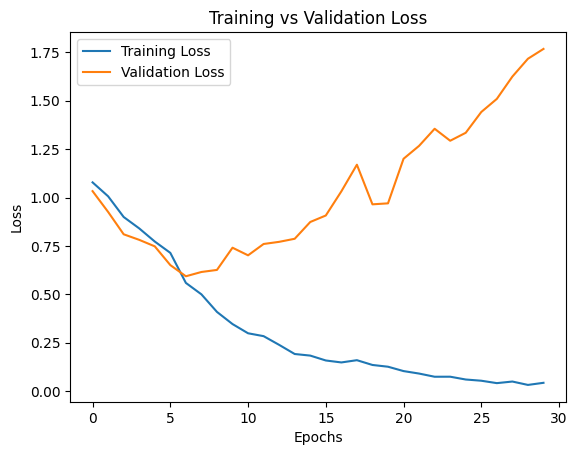

In [17]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

#### Training vs Validation Accuracy

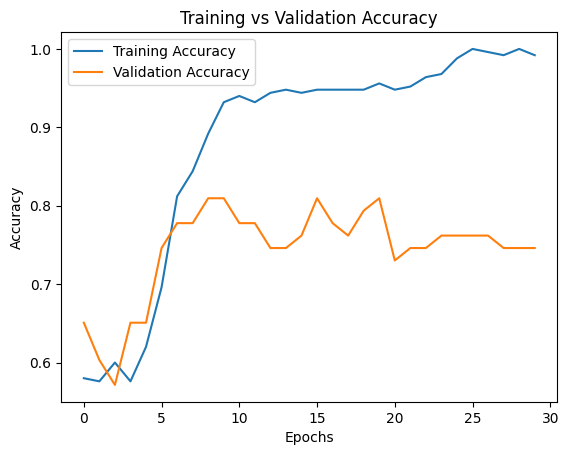

In [18]:
plt.figure()
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

### Word Embedding Analysis

Getting the embedding layer and then getting the word embedding weights

In [19]:
embedding_layer=model.layers[0]
word_embeddings=embedding_layer.get_weights()[0]

print("Shape of word embeddings:",word_embeddings.shape)
print("First 5 embedding vectors:")
print(word_embeddings[:5])

Shape of word embeddings: (10000, 128)
First 5 embedding vectors:
[[ 1.45168588e-01 -1.51016682e-01  6.25790358e-02 -1.03204787e-01
  -2.17929721e-01  6.02380820e-02  8.08796510e-02  1.02745146e-02
   4.79112901e-02  6.36821464e-02 -1.52642041e-01 -2.23395694e-02
   2.50747297e-02  1.24319242e-02  4.64691035e-02  1.87027324e-02
  -8.68127402e-03 -1.61317199e-01 -5.80770485e-02 -4.29919409e-03
   3.70725654e-02  5.29217795e-02 -4.57289889e-02 -3.15884463e-02
  -6.18528388e-02  2.26489287e-02  2.82685086e-02  7.57725090e-02
   1.30434349e-01 -1.50337266e-02 -1.12252366e-02  6.32850407e-03
   2.34334469e-02 -1.51765649e-03 -9.60972458e-02 -1.13699213e-02
   6.33032247e-02 -3.78427543e-02 -4.55500651e-03  1.79139096e-02
  -9.02901664e-02 -6.05932437e-02  1.55424336e-02 -7.23201111e-02
   8.80865827e-02  1.94065999e-02 -1.76903218e-01 -4.18117493e-02
  -1.43138254e-02 -4.71675158e-01 -2.45566238e-02  1.39631284e-02
  -5.06030247e-02 -2.65034325e-02  1.90934557e-02  1.54025694e-02
  -1.47043

#### Checking first five tokenized words

In [20]:
list(tokenizer.word_index.items())[:5]

[('<OOV>', 1), ('the', 2), ('i', 3), ('to', 4), ('and', 5)]

#### Getting token for the word product

In [21]:
tokenizer.word_index['product']

105

#### Getting word embedding for product

In [22]:
word_embeddings[105]

array([ 0.06730048,  0.04214451, -0.04031004,  0.04051344, -0.05057542,
       -0.05565029, -0.00559849,  0.00950386, -0.00418224, -0.05836363,
       -0.02633577,  0.0597579 , -0.02671798, -0.07038221,  0.05897257,
       -0.05779714,  0.05541018,  0.0638672 , -0.02505936,  0.05245474,
        0.01510122, -0.02591183,  0.01023433,  0.00629338,  0.05313271,
        0.06788409, -0.01851747, -0.09189105, -0.00470093, -0.06579263,
        0.06924351, -0.00889358, -0.01850477, -0.0493167 , -0.01450997,
       -0.02593887,  0.01213311,  0.06071584, -0.0346894 , -0.05513879,
        0.0265673 , -0.04363349,  0.10044664,  0.0204883 , -0.01375967,
        0.09167195, -0.05855185, -0.04976503, -0.0695113 , -0.04699783,
        0.04193224,  0.01095822, -0.02942636, -0.01875124,  0.07056603,
       -0.07381929,  0.04297712, -0.00934075, -0.0054457 , -0.03394931,
       -0.04452763, -0.04787849,  0.04592682, -0.08622485, -0.01877525,
       -0.00877408,  0.02594585, -0.0075992 , -0.03222788,  0.01

### Inspecting embedding magnitudes

#### Embedding magnitude gives the importance of the word in the model

larger magnitude means more important the word, so inorder to get the top 10 important word first getting the embedding magnitudes and then sorting in the descending order of the magnitude

In [23]:
embedding_magnitudes=np.linalg.norm(word_embeddings,axis=1)
print("Shape of embedding magnitudes:",embedding_magnitudes.shape)

Shape of embedding magnitudes: (10000,)


In [24]:
embedding_magnitudes

array([1.0759362 , 0.30701724, 1.0555972 , ..., 0.31267855, 0.3206252 ,
       0.3087604 ], dtype=float32)

### Getting top 10 important words

In [25]:
top_words=sorted(tokenizer.word_index.items(),key=lambda x:embedding_magnitudes[x[1]],reverse=True)[:10]
top_words

[('junk', 843),
 ('wo', 323),
 ('the', 2),
 ('customer', 241),
 ('camerai', 876),
 ('weeks', 281),
 ('sucks', 626),
 ('perfect', 253),
 ('returned', 534),
 ('beside', 1936)]

### Sample Review Analysis
#### Creating a sentiment map for prediction label

In [26]:
label_map={
    0:"negative",
    1:"neutral",
    2:"positive"
}

#### Checking with two sample positive and negative reviews

In [27]:
sample_reviews=[
    "I absolutely love this product. The quality is excellent and it works perfectly.",
    "This is the worst product I have ever bought. It is broken and completely useless."
]

sample_seq=tokenizer.texts_to_sequences(sample_reviews)
sample_pad=pad_sequences(sample_seq, maxlen=100, padding='post')

predictions=model.predict(sample_pad)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


array([[3.1176485e-05, 1.8487818e-04, 9.9978393e-01],
       [1.1213430e-01, 8.6286235e-01, 2.5003275e-02]], dtype=float32)

#### Predicting output labels

In [28]:
predicted_labels=np.argmax(predictions,axis=1)
predicted_labels

array([2, 1])

#### Output of label and confidence score

In [29]:
for review,label,prob in zip(sample_reviews,predicted_labels,predictions):
    print("Review:",review)
    print("Predicted Sentiment:",label_map[label])
    print("Confidence Score:",np.max(prob)*100,"%")

Review: I absolutely love this product. The quality is excellent and it works perfectly.
Predicted Sentiment: positive
Confidence Score: 99.97839 %
Review: This is the worst product I have ever bought. It is broken and completely useless.
Predicted Sentiment: neutral
Confidence Score: 86.28623 %
